In [21]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [9]:
images = os.listdir("images")

for idx, image in enumerate(images):
    image = Image.open(os.path.join("images", image)).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()
    label = model.config.id2label[predicted_class_idx]
    print(f"Predicted class: {label}, Original Image: {images[idx]}")


Predicted class: convertible, Original Image: car.jpg
Predicted class: tabby, tabby cat, Original Image: cat.jpg


Predicted class: convertible, Original Image: car.jpg


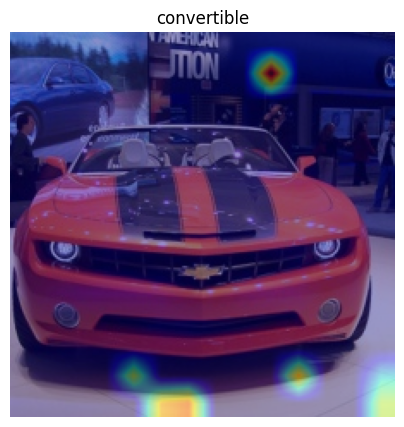

Predicted class: tabby, tabby cat, Original Image: cat.jpg


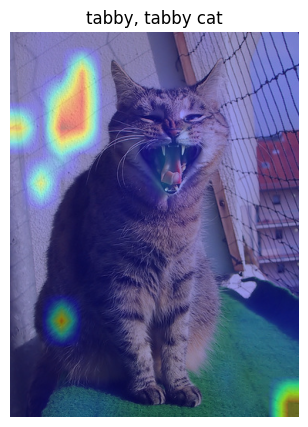

In [ ]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    attn_implementation="eager"
)

model.config.output_attentions = True
model.eval()

for idx, img_name in enumerate(images):

    image = Image.open(os.path.join("images", img_name)).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    # Forward pass with attention enabled
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()
    label = model.config.id2label[predicted_class_idx]

    print(f"Predicted class: {label}, Original Image: {img_name}")

    attentions = outputs.attentions
    last_layer_attn = attentions[-1]  

    attn_avg = last_layer_attn.mean(dim=1)

    cls_attn = attn_avg[0, 0, 1:]  

    cls_attn = cls_attn.cpu().numpy()

    num_patches = cls_attn.shape[0]
    grid_size = int(np.sqrt(num_patches))
    attention_map = cls_attn.reshape(grid_size, grid_size)

    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

    attention_img = Image.fromarray(np.uint8(attention_map * 255))
    attention_img = attention_img.resize(image.size, resample=Image.BILINEAR)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.imshow(attention_img, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"{label}")
    plt.show()



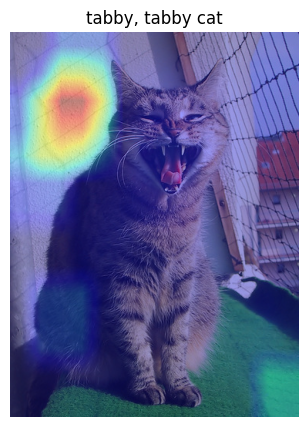

In [18]:
last_k = 4
attn_stack = torch.stack(attentions[-last_k:])         # [K, B, H, T, T]
attn_mean = attn_stack.mean(dim=0)                     # [B, H, T, T]

# 2) Average heads
attn_mean = attn_mean.mean(dim=1)                      # [B, T, T]

# 3) CLS -> patches
cls_attn = attn_mean[0, 0, 1:]                         # [num_patches]

# 4) Reshape to patch grid
num_patches = cls_attn.shape[0]
grid_size = int(np.sqrt(num_patches))
attn_map = cls_attn.reshape(grid_size, grid_size)      # [G, G]

# 5) Smooth on patch grid (simple avg pooling)
attn_map = attn_map[None, None]                        # 1x1xGxG
attn_map = torch.nn.functional.avg_pool2d(attn_map, kernel_size=3, stride=1, padding=1)[0,0]

# 6) Normalize
attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

# 7) Upsample to image size
H_img, W_img = image.size[1], image.size[0]
attn_up = torch.nn.functional.interpolate(
    attn_map[None, None], size=(H_img, W_img), mode="bilinear", align_corners=False
)[0,0].cpu().numpy()

# 8) Overlay
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.imshow(attn_up, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title(f"{label}")
plt.show()


Image: images\car.jpg
mask=0.0 | random: convertible (0.556) | center: convertible (0.575)


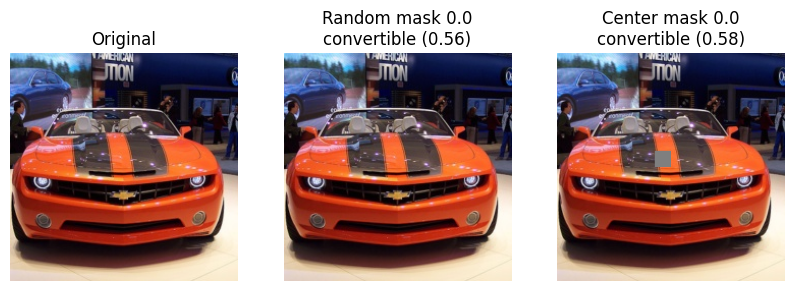

mask=0.3 | random: convertible (0.918) | center: convertible (0.933)


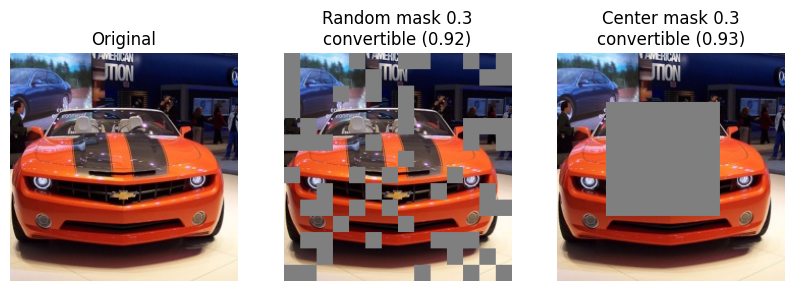

mask=0.6 | random: convertible (0.676) | center: sports car, sport car (0.939)


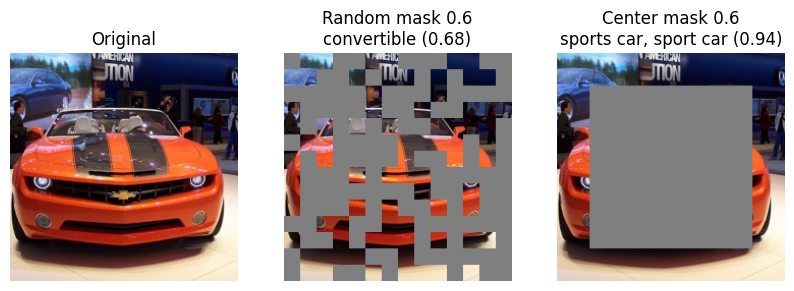


Image: images\cat.jpg
mask=0.0 | random: tabby, tabby cat (0.698) | center: tabby, tabby cat (0.695)


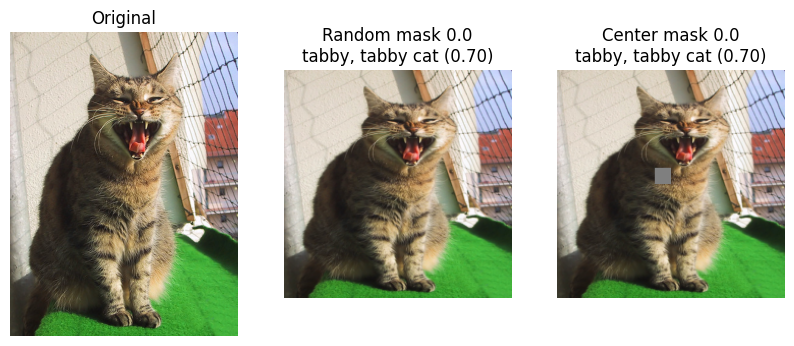

mask=0.3 | random: tabby, tabby cat (0.504) | center: tabby, tabby cat (0.770)


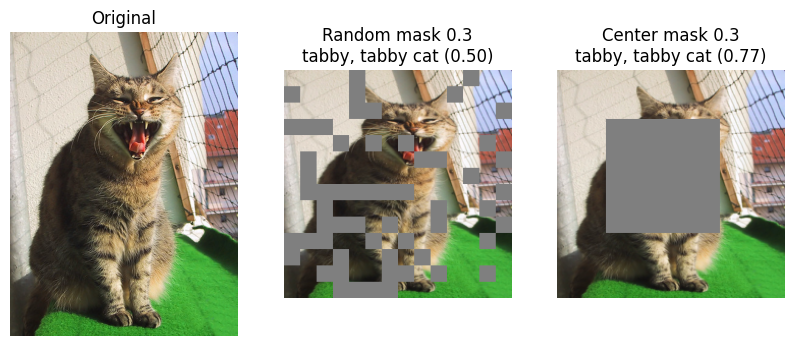

mask=0.6 | random: tabby, tabby cat (0.458) | center: Angora, Angora rabbit (0.544)


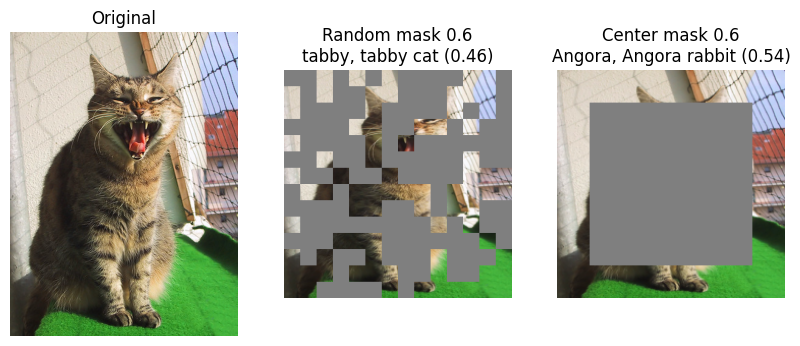

In [25]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

images = os.listdir("images")
image_paths = [os.path.join("images", img) for img in images]

def apply_patch_mask(pixel_values, mask_ratio=0.3, mode="random", patch_size=16):
    B, C, H, W = pixel_values.shape
    gh, gw = H // patch_size, W // patch_size
    num_patches = gh * gw

    mask = torch.zeros((B, gh, gw), device=pixel_values.device)

    if mode == "random":
        num_mask = int(mask_ratio * num_patches)
        for b in range(B):
            idx = torch.randperm(num_patches, device=pixel_values.device)[:num_mask]
            mask.view(B, -1)[b, idx] = 1.0

    elif mode == "center":
        block_area = int(mask_ratio * num_patches)
        block_size = max(1, int(np.sqrt(block_area)))
        sh = (gh - block_size) // 2
        sw = (gw - block_size) // 2
        mask[:, sh:sh+block_size, sw:sw+block_size] = 1.0
    else:
        raise ValueError("mode must be 'random' or 'center'")

    # expand to pixel space: [B, C, H, W]
    mask = mask[:, None, :, :].repeat(1, C, 1, 1)
    mask = mask.repeat_interleave(patch_size, dim=2).repeat_interleave(patch_size, dim=3)

    masked = pixel_values.clone()
    masked[mask.bool()] = 0.0
    return masked

@torch.no_grad()
def predict(pixel_values):
    outputs = model(pixel_values=pixel_values)
    probs = torch.softmax(outputs.logits, dim=-1)
    conf, idx = probs.max(dim=-1)
    label = model.config.id2label[idx.item()]
    return label, conf.item()

def to_img(pv_tensor):
    # de-normalize using processor stats
    device = pv_tensor.device
    mean = torch.tensor(processor.image_mean, device=device).view(1,3,1,1)
    std  = torch.tensor(processor.image_std,  device=device).view(1,3,1,1)
    x = pv_tensor * std + mean
    x = x.clamp(0,1)[0].permute(1,2,0).cpu().numpy()
    return x

mask_ratios = [0.0, 0.3, 0.6]

for path in image_paths:
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    pv = inputs["pixel_values"]

    print(f"\nImage: {path}")
    for r in mask_ratios:
        # random
        pv_rand = apply_patch_mask(pv, mask_ratio=r, mode="random", patch_size=model.config.patch_size)
        label_r, conf_r = predict(pv_rand)

        # center
        pv_center = apply_patch_mask(pv, mask_ratio=r, mode="center", patch_size=model.config.patch_size)
        label_c, conf_c = predict(pv_center)

        print(f"mask={r:.1f} | random: {label_r} ({conf_r:.3f}) | center: {label_c} ({conf_c:.3f})")

        # visualize
        imgs = [np.array(image)/255.0, to_img(pv_rand), to_img(pv_center)]
        titles = [
            "Original",
            f"Random mask {r:.1f}\n{label_r} ({conf_r:.2f})",
            f"Center mask {r:.1f}\n{label_c} ({conf_c:.2f})"
        ]

        plt.figure(figsize=(10, 4))
        for i, (im, t) in enumerate(zip(imgs, titles)):
            plt.subplot(1, 3, i+1)
            plt.imshow(im)
            plt.title(t)
            plt.axis("off")
        plt.show()